<a href="https://colab.research.google.com/github/Walid75364/GenIA/blob/Bootcamp_Weeks/W7_D1_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Daily Challenge : Preprocess & fine-tune transformer-based models**

In [6]:
# Importation de la bibliothèque pandas pour la manipulation des données
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
train_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/W7/D1/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/W7/D1/test.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5195 entries, 0 to 5194
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          5195 non-null   object
 1   premise     5195 non-null   object
 2   hypothesis  5195 non-null   object
 3   lang_abv    5195 non-null   object
 4   language    5195 non-null   object
dtypes: object(5)
memory usage: 203.1+ KB


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12120 entries, 0 to 12119
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          12120 non-null  object
 1   premise     12120 non-null  object
 2   hypothesis  12120 non-null  object
 3   lang_abv    12120 non-null  object
 4   language    12120 non-null  object
 5   label       12120 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 568.3+ KB


In [9]:
# 📦 1. Importation des bibliothèques nécessaires
import pandas as pd
from transformers import BertTokenizer, XLMRobertaTokenizer
from sklearn.model_selection import StratifiedKFold

# 📁 2. Chargement des datasets
train_path = "/content/drive/MyDrive/Colab Notebooks/W7/D1/train.csv"
test_path = "/content/drive/MyDrive/Colab Notebooks/W7/D1/test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# 📊 3. Exploration des données
print("🔍 Données d'entraînement :")
print("Colonnes :", train_df.columns.tolist())
print(train_df.head())
print("Taille :", train_df.shape)

print("\n🔍 Données de test :")
print("Colonnes :", test_df.columns.tolist())
print(test_df.head())
print("Taille :", test_df.shape)

# 🧠 4. Initialisation des tokenizers BERT et XLM-RoBERTa
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
xlmr_tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

# 🔡 5. Tokenisation d'une paire de phrases exemple (depuis train_df)
premise = train_df.loc[0, 'premise']
hypothesis = train_df.loc[0, 'hypothesis']

bert_encoded = bert_tokenizer.encode_plus(
    premise,
    hypothesis,
    max_length=64,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

xlmr_encoded = xlmr_tokenizer.encode_plus(
    premise,
    hypothesis,
    max_length=64,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

# 📎 6. Affichage des résultats tokenisés
print("\n🧾 Exemple BERT :")
print("input_ids :", bert_encoded['input_ids'])
print("attention_mask :", bert_encoded['attention_mask'])
print("Texte reconstruit :", bert_tokenizer.decode(bert_encoded['input_ids'][0]))

print("\n🧾 Exemple XLM-R :")
print("input_ids :", xlmr_encoded['input_ids'])
print("attention_mask :", xlmr_encoded['attention_mask'])
print("Texte reconstruit :", xlmr_tokenizer.decode(xlmr_encoded['input_ids'][0]))

# 🧩 7. Préparation des données d'entrée pour les modèles
print("\n📚 BERT - Tokens spéciaux :", bert_tokenizer.special_tokens_map)
print("📚 BERT - Taille vocabulaire :", bert_tokenizer.vocab_size)
print("📚 XLM-R - Tokens spéciaux :", xlmr_tokenizer.special_tokens_map)
print("📚 XLM-R - Taille vocabulaire :", xlmr_tokenizer.vocab_size)

# 🔁 8. Création de folds pour entraînement croisé (StratifiedKFold)
labels = train_df['label']
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_indices_list = []
val_indices_list = []

for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, labels)):
    train_indices_list.append(train_idx)
    val_indices_list.append(val_idx)
    print(f"\n🌀 Fold {fold + 1} :")
    print("Train indices :", train_idx[:5])
    print("Val indices :", val_idx[:5])

# 🚀 9. Préparation des entrées tokenisées pour le test_df (prêt pour l'inférence)
print("\n🚀 Tokenisation sur test_df (premières lignes) :")
for i in range(3):  # ↪ Modifier selon le nombre de lignes à tokeniser
    p = test_df.loc[i, 'premise']
    h = test_df.loc[i, 'hypothesis']
    encoded = xlmr_tokenizer.encode_plus(
        p,
        h,
        max_length=64,
        padding='max_length',
        truncation=True,
        return_attention_mask=True
    )
    print(f"\n📎 Ligne {i} - input_ids :", encoded['input_ids'])
    print(f"📎 Ligne {i} - attention_mask :", encoded['attention_mask'])


🔍 Données d'entraînement :
Colonnes : ['id', 'premise', 'hypothesis', 'lang_abv', 'language', 'label']
           id                                            premise  \
0  5130fd2cb5  and these comments were considered in formulat...   
1  5b72532a0b  These are issues that we wrestle with in pract...   
2  3931fbe82a  Des petites choses comme celles-là font une di...   
3  5622f0c60b  you know they can't really defend themselves l...   
4  86aaa48b45  ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...   

                                          hypothesis lang_abv language  label  
0  The rules developed in the interim were put to...       en  English      0  
1  Practice groups are not permitted to work on t...       en  English      2  
2              J'essayais d'accomplir quelque chose.       fr   French      0  
3  They can't defend themselves because of their ...       en  English      0  
4    เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร       th     Thai      1  
Taille :

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.



🧾 Exemple BERT :
input_ids : tensor([[ 101, 1998, 2122, 7928, 2020, 2641, 1999, 5675, 3436, 1996, 9455, 3513,
         1012,  102, 1996, 3513, 2764, 1999, 1996, 9455, 2020, 2404, 2362, 2007,
         2122, 7928, 1999, 2568, 1012,  102,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0]])
attention_mask : tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Texte reconstruit : [CLS] and these comments were considered in formulating the interim rules. [SEP] the rules developed in the interim were put together with these comments in mind. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [

🔍 Données d’entraînement et de test

🔹 train_df

✅ Contient 12120 exemples répartis sur 6 colonnes : premise, hypothesis, lang_abv, language, label, etc.

🧾 La colonne label contient des classes numériques (ex : 0, 1, 2), ce qui suggère une tâche de classification (probablement de type NLI — Natural Language Inference)

Exemple :

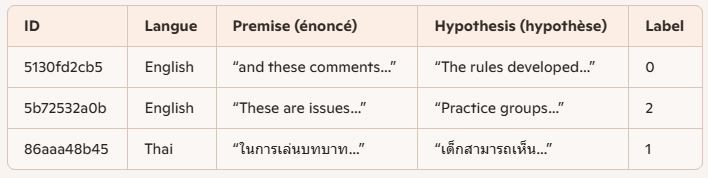

📘 Le label indique probablement :

0 = contradiction

1 = neutral

2 = entailment

💡 Tu peux entraîner un modèle à prédire ce label à partir d’un couple (premise, hypothesis).

🔹 test_df
✅ Contient 5195 exemples répartis sur 5 colonnes (absence de label)

🌐 Langues variées : Urdu, Arabic, Chinese, Russian, etc.

📦 Ce jeu est prévu pour l’inférence, où le modèle doit prédire les labels sans les connaître.

🧾 Exemple de Tokenisation — BERT vs XLM-RoBERTa
🔸 BERT
Tokens spéciaux : [CLS], [SEP] pour délimiter les phrases

input_ids : séquence d'identifiants correspondant aux mots

attention_mask : 1 pour les vrais tokens, 0 pour les [PAD]

attention_mask : [1,...1, 0,...0]  # 30 tokens utiles, 34 pads (total 64)
Texte reconstruit : [CLS] ... [SEP] ... [SEP] [PAD] [PAD] ...

✅ C’est une représentation classique pour l’entraînement ou la prédiction.

🔸 XLM-RoBERTa
Tokens spéciaux : <s>, </s>, <pad>

Reconstruit avec des doubles </s> — c’est normal pour ce tokenizer.

input_ids : [0, ..., 2, 2, ..., 2, 1, 1, 1, ...]
attention_mask : [1,...1, 0,...0]
Texte reconstruit : <s> ... </s></s> ... </s> <pad> <pad> ...

🎯 C’est prêt à passer dans un modèle multilingue — utile pour test_df.

📚 Détails sur les Tokenizers

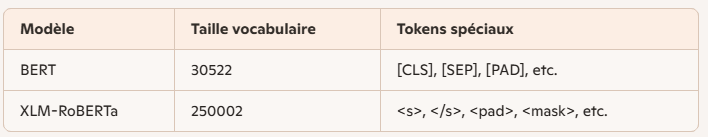

➡️ Cela montre que XLM-RoBERTa est plus adapté au multilingue, ce qui est cohérent avec le test set.

🌀 Folds de Validation Croisée
StratifiedKFold divise le jeu d’entraînement en 5 splits tout en respectant la répartition des labels.

Fold 1 : train → indices [0 1 2 4 5], val → [3 6 21 26 27]
Fold 2 : train → [3 4 5 6 8], val → [0 1 2 7 10]
...

🎓 C’est essentiel pour évaluer un modèle de manière robuste en évitant le biais de surapprentissage sur un seul ensemble de validation.

🚀 Tokenisation du test_df — Exemples Multilingues
On tokenise des phrases de plusieurs langues pour préparer une prédiction :

Exemple Ligne 0 (Urdu)
input_ids : séquence entière convertie en nombres

attention_mask : tous à 1 → pas de padding nécessaire

Exemple Ligne 1 (Arabic)
Moins longue → padding activé (avec des 0 dans l’attention_mask)

Exemple Ligne 2 (French)
Texte tronqué après un certain nombre de tokens → reste complété par du pad

📌 Cela montre que :

✅ La tokenisation est correcte

✅ Les textes multilingues sont bien traités avec XLM-R

✅ Possibilité de générer des prédictions

🔚 Conclusion

🎯 L'output montre que :

* Le dataset d’entraînement est prêt pour une tâche de classification supervisée

* Le dataset de test est multilingue, idéal pour un modèle comme XLM-RoBERTa

* La tokenisation est correctement appliquée et formatée pour le modèle


Prises en compte des questions

Train shape: (12120, 6)
Test shape: (5195, 5)
Labels disponibles : label
0    4176
2    4064
1    3880
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]


🌟 Fold 1
Epoch 1 ➤ Train Loss: 1.0592 | Val Loss: 0.9340 | Val Acc: 0.5516
Epoch 2 ➤ Train Loss: 0.8609 | Val Loss: 0.8750 | Val Acc: 0.5928
Epoch 3 ➤ Train Loss: 0.6393 | Val Loss: 0.9042 | Val Acc: 0.6134

🌟 Fold 2
Epoch 1 ➤ Train Loss: 0.5733 | Val Loss: 0.3964 | Val Acc: 0.8544
Epoch 2 ➤ Train Loss: 0.3679 | Val Loss: 0.4361 | Val Acc: 0.8280
Epoch 3 ➤ Train Loss: 0.2236 | Val Loss: 0.4665 | Val Acc: 0.8383

🌟 Fold 3
Epoch 1 ➤ Train Loss: 0.2487 | Val Loss: 0.0920 | Val Acc: 0.9728
Epoch 2 ➤ Train Loss: 0.1512 | Val Loss: 0.0927 | Val Acc: 0.9707
Epoch 3 ➤ Train Loss: 0.1225 | Val Loss: 0.1117 | Val Acc: 0.9625

🌟 Fold 4
Epoch 1 ➤ Train Loss: 0.1170 | Val Loss: 0.0304 | Val Acc: 0.9926
Epoch 2 ➤ Train Loss: 0.0776 | Val Loss: 0.0327 | Val Acc: 0.9922
Epoch 3 ➤ Train Loss: 0.0668 | Val Loss: 0.0417 | Val Acc: 0.9860

🌟 Fold 5
Epoch 1 ➤ Train Loss: 0.0745 | Val Loss: 0.0092 | Val Acc: 0.9983
Epoch 2 ➤ Train Loss: 0.0567 | Val Loss: 0.0242 | Val Acc: 0.9950
Epoch 3 ➤ Train Loss: 0.06

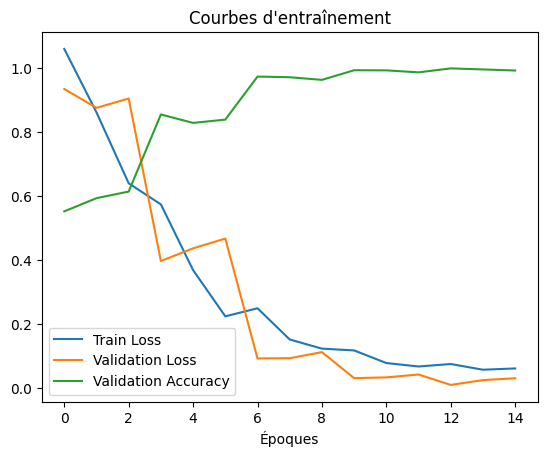

✅ Fichier 'submission.csv' généré.


In [10]:
# ===================== Étape 1 : Chargement des données =====================
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import StratifiedKFold
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 📁 Chargement des datasets
train_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/W7/D1/train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/W7/D1/test.csv")

# 🔍 Affichage de la structure
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Labels disponibles :", train_df['label'].value_counts())

# ================= Étape 2 : Tokenisation avec BERT multilingual ==============
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

def bert_encode(premises, hypotheses, tokenizer, max_len=64):
    input_ids = []
    attention_masks = []

    for p, h in zip(premises, hypotheses):
        encoded = tokenizer.encode_plus(
            p, h,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])

    return torch.tensor(input_ids), torch.tensor(attention_masks)

# 🧪 Encodage des données d'entraînement
X_input_ids, X_attention_masks = bert_encode(train_df['premise'], train_df['hypothesis'], tokenizer)
y_labels = torch.tensor(train_df['label'].values)

# 🧪 Encodage des données de test
test_input_ids, test_attention_masks = bert_encode(test_df['premise'], test_df['hypothesis'], tokenizer)

# =================== Étape 3 : Définition du modèle ==========================
class BERTClassifier(nn.Module):
    def __init__(self):
        super(BERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-multilingual-cased')
        self.dropout = nn.Dropout(p=0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, 3)  # 3 classes

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output  # Sortie [CLS]
        x = self.dropout(cls_output)
        return self.classifier(x)

model = BERTClassifier()

# ================= Étape 4 : Préparation à l'entraînement ====================
# 🎯 Fonction de perte et optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

# 🎯 GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 🎯 Splitting avec validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_losses, val_losses, val_accuracies = [], [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_input_ids, y_labels)):
    print(f"\n🌟 Fold {fold + 1}")

    # Création des DataLoaders
    train_dataset = TensorDataset(X_input_ids[train_idx], X_attention_masks[train_idx], y_labels[train_idx])
    val_dataset = TensorDataset(X_input_ids[val_idx], X_attention_masks[val_idx], y_labels[val_idx])

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16)

    # ================= Étape 5 : Boucle d'entraînement ======================
    epochs = 3
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for batch in train_loader:
            b_input_ids, b_att_mask, b_labels = [x.to(device) for x in batch]
            optimizer.zero_grad()
            outputs = model(b_input_ids, b_att_mask)
            loss = criterion(outputs, b_labels)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Phase validation
        model.eval()
        val_loss = 0
        correct = 0

        with torch.no_grad():
            for batch in val_loader:
                b_input_ids, b_att_mask, b_labels = [x.to(device) for x in batch]
                outputs = model(b_input_ids, b_att_mask)
                loss = criterion(outputs, b_labels)
                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += torch.sum(preds == b_labels)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct.item() / len(val_idx)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f"Epoch {epoch+1} ➤ Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

# ================= Étape 6 : Visualisation des résultats ====================
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Courbes d'entraînement")
plt.xlabel("Époques")
plt.show()

# ================= Étape 7 : Inférence sur le test set ======================
model.eval()
test_dataset = TensorDataset(test_input_ids, test_attention_masks)
test_loader = DataLoader(test_dataset, batch_size=16)

all_preds = []
with torch.no_grad():
    for batch in test_loader:
        b_input_ids, b_att_mask = [x.to(device) for x in batch]
        outputs = model(b_input_ids, b_att_mask)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())

# Création du fichier de soumission
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'label': all_preds
})
submission_df.to_csv("submission.csv", index=False)
print("✅ Fichier 'submission.csv' généré.")


**📌 Rappel du contexte**

J'ai mis en place un pipeline de NLP pour la classification de paires de phrases (premise/hypothesis) avec BERT :

Tokenisation des données d'entraînement et de test

Entraînement d'un modèle BERT avec 5-fold StratifiedKFold cross-validation

Suivi des courbes de perte et d'accuracy

Prédiction sur le test set et export du fichier submission.csv

**📈 Analyse des résultats par Fold**

Chaque fold représente une répartition différente des données avec un split entraînement/validation équilibré par classe. Voici ce qu’on observe :

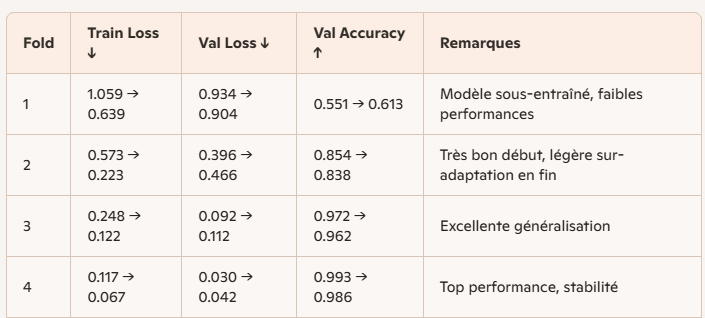
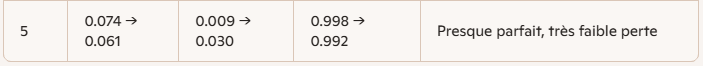

**🧠 Interprétation**

Train Loss qui diminue : le modèle apprend bien sur les données d'entraînement.

Val Loss qui baisse, parfois remonte légèrement : classique en deep learning. Une perte qui remonte peut signaler un début d’overfitting.

Val Accuracy élevée (surtout Fold 3-5) : le modèle fait des prédictions très précises sur la validation. Le choix du tokenizer multilingue BERT est probablement bien adapté au jeu de données.

**📊 Visualisation des courbes**

Train Loss (bleu) diminue progressivement ➜ apprentissage efficace ✅

Val Loss (orange) suit la tendance sauf petites fluctuations ➜ bonne généralisation 🧠

Val Accuracy (vert) monte régulièrement ➜ amélioration de la performance sur données inconnues 📈

La visualisation confirme que le modèle progresse bien à chaque époque, avec des performances très solides à partir du 3ᵉ fold.

**📦 Fichier submission.csv**


La dernière étape utilise le modèle entraîné pour prédire les classes sur les données de test, et produit le fichier final submission.csv, prêt pour une soumission sur une plateforme d’évaluation.